<a href="https://colab.research.google.com/github/Murcha1990/GenModels_AI26/blob/main/Seminars_Base/Sem1_GPT/sem1_image_gpt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GPT, который рисует картинки

В текстовом GPT картинка мира такая: **последовательность токенов → предскажи следующий**.

Оказывается, картинку тоже можно превратить в последовательность — просто развернуть пиксели в строку:

```
┌───┬───┬───┐
│ 0 │ 1 │ 2 │
├───┼───┼───┤        →   [0, 1, 2, 3, 4, 5, 6, 7, 8]
│ 3 │ 4 │ 5 │            «читаем» слева направо, сверху вниз
├───┼───┼───┤
│ 6 │ 7 │ 8 │
└───┴───┴───┘
```

И тогда **модель не меняется вообще**: тот же декодер, та же каузальная маска, та же задача
«предскажи следующий токен». Меняется только словарь: вместо слов — цвета пикселей.

```
текст:    «кот»  «сидит»  «на»   →  предсказать «подоконнике»
картинка:  ▪ ▪ ▪ ▫ ▫ ▪ ▪         →  предсказать следующий пиксель
```

Так работали ImageGPT, DALL·E 1, Parti — и так же (с оговорками) генерирует картинки GPT-4o.

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

torch.manual_seed(42)
np.random.seed(42)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11

# Палитра: -1 — ещё не нарисовано, 0 — фон, 1 и 2 — два цвета фигуры
PALETTE = ListedColormap(['#ffffff', '#ececec', '#f39c12', '#2980b9'])

def show(ax, img, title='', fontsize=9):
    n = img.shape[0]
    ax.imshow(img, cmap=PALETTE, vmin=-1, vmax=2)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xticks(np.arange(-.5, n, 1), minor=True)
    ax.set_yticks(np.arange(-.5, n, 1), minor=True)
    ax.grid(which='minor', color='white', linewidth=0.8)   # сетка пикселей
    ax.tick_params(which='minor', length=0)
    ax.set_title(title, fontsize=fontsize)

---
## 1. Картинка → последовательность токенов

Возьмём совсем маленькие картинки **8×8** и всего три «цвета»: фон и два цвета фигуры.
Тогда одна картинка — это строка из 64 чисел, то есть 64 токена.

**А где здесь промпт?** В настоящих моделях перед картинкой в ту же последовательность
кладут токены текста. У нас будет мини-версия: один токен-промпт в самом начале —
«квадрат», «полоса |» или «полоса —».

```
[промпт] [пиксель 1] [пиксель 2] ... [пиксель 64]
   ↑
   с него всё начинается — именно он определяет, что нарисуется
```

Обучающий пример устроен как в текстовом GPT: вход — вся последовательность без последнего
токена, ответ — она же, сдвинутая на один шаг вправо.

In [ ]:
SIZE    = 8              # картинка 8×8
SEQ_LEN = SIZE * SIZE    # 64 пикселя = 64 позиции в последовательности
VOCAB   = 6              # 0,1,2 — цвета пикселей;  3,4,5 — токены-промпты

SQUARE, VBAR, HBAR = 3, 4, 5
PROMPT_NAME = {SQUARE: 'квадрат', VBAR: 'полоса |', HBAR: 'полоса —'}

def make_image(prompt):
    # Рисует картинку, которая соответствует промпту
    img   = np.zeros((SIZE, SIZE), dtype=np.int64)
    color = np.random.randint(1, 3)                   # цвет фигуры: 1 или 2
    if prompt == SQUARE:
        r, c = np.random.randint(0, SIZE - 2, size=2)
        img[r:r + 3, c:c + 3] = color
    elif prompt == VBAR:
        c = np.random.randint(0, SIZE - 1)
        img[:, c:c + 2] = color
    else:
        r = np.random.randint(0, SIZE - 1)
        img[r:r + 2, :] = color
    return img

N       = 384                                          # размер обучающей выборки
prompts = np.random.choice([SQUARE, VBAR, HBAR], size=N)
images  = np.stack([make_image(p) for p in prompts])

# [промпт] + 64 пикселя, развёрнутых построчно
data   = torch.tensor(np.concatenate([prompts[:, None], images.reshape(N, -1)], axis=1))
Xs, Ys = data[:, :-1], data[:, 1:]                     # вход и ответ со сдвигом на 1

print('последовательность:', tuple(data.shape), ' вход:', tuple(Xs.shape), ' ответ:', tuple(Ys.shape))

последовательность: (384, 65)  вход: (384, 64)  ответ: (384, 64)


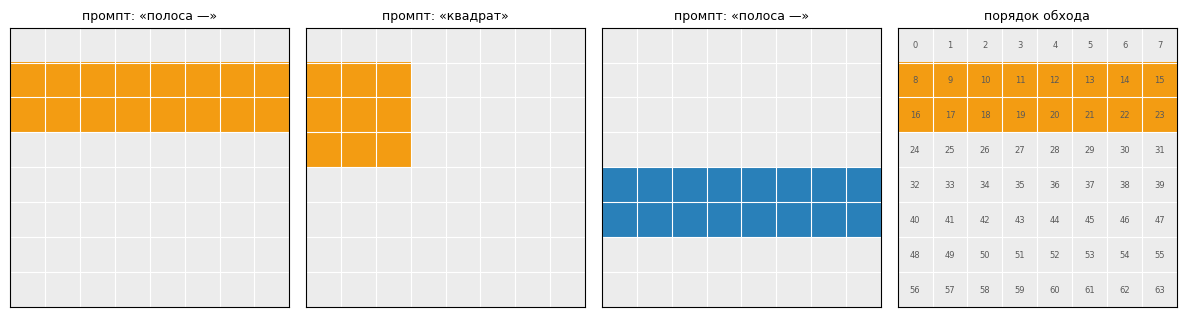

Первая картинка как строка токенов:
[0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0] ...


In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3.2))

for ax, i in zip(axes[:3], range(3)):
    show(ax, images[i], f'промпт: «{PROMPT_NAME[prompts[i]]}»')

# Порядок, в котором GPT «читает» и потом рисует пиксели
show(axes[3], images[0], 'порядок обхода')
for i in range(SIZE):
    for j in range(SIZE):
        axes[3].text(j, i, i * SIZE + j, ha='center', va='center', fontsize=6, color='0.35')

plt.tight_layout(); plt.show()

print('Первая картинка как строка токенов:')
print(images[0].reshape(-1)[:32], '...')

---
## 2. Модель — тот же самый декодер

Ниже — дословно та же архитектура, что и в текстовом GPT: каузальное внимание (будущее закрыто маской),
блок трансформера, эмбеддинги токенов и позиций, линейная «голова» с логитами.

Единственное отличие: словарь теперь состоит из цветов пикселей и токенов-промптов,
а «позиция» — это номер пикселя в развёртке.

In [ ]:
class CausalSelfAttention(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.Wq = nn.Linear(d_model, d_model, bias=False)
        self.Wk = nn.Linear(d_model, d_model, bias=False)
        self.Wv = nn.Linear(d_model, d_model, bias=False)
        self.Wo = nn.Linear(d_model, d_model, bias=False)

    def forward(self, x):                              # x: (B, T, D)
        B, T, D = x.shape
        Q, K, V = self.Wq(x), self.Wk(x), self.Wv(x)
        scores  = Q @ K.transpose(-2, -1) / D ** 0.5

        # Закрываем будущее: пиксель не имеет права подглядывать на ещё не нарисованные
        mask   = torch.triu(torch.ones(T, T, device=x.device), diagonal=1).bool()
        scores = scores.masked_fill(mask, float('-inf'))

        weights = torch.softmax(scores, dim=-1)
        return self.Wo(weights @ V), weights


class TransformerBlock(nn.Module):
    def __init__(self, d_model, d_ff):
        super().__init__()
        self.attn  = CausalSelfAttention(d_model)
        self.ff    = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.ReLU(), nn.Linear(d_ff, d_model)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        a, w = self.attn(x)
        x    = self.norm1(x + a)
        x    = self.norm2(x + self.ff(x))
        return x, w


class ImageGPT(nn.Module):
    def __init__(self, vocab_size, seq_len, d_model=64, d_ff=128, n_blocks=2):
        super().__init__()
        self.embed  = nn.Embedding(vocab_size, d_model)   # что за токен
        self.pos    = nn.Embedding(seq_len, d_model)      # какой он по счёту
        self.blocks = nn.ModuleList([TransformerBlock(d_model, d_ff) for _ in range(n_blocks)])
        self.head   = nn.Linear(d_model, vocab_size)      # логиты → следующий пиксель

    def forward(self, x):                                 # x: (B, T)
        B, T = x.shape
        h = self.embed(x) + self.pos(torch.arange(T, device=x.device).expand(B, -1))
        for block in self.blocks:
            h, w = block(h)
        return self.head(h), w                            # (B, T, vocab_size)

---
## 3. Обучение: Next **Pixel** Prediction

Ровно та же функция потерь, что и для текста: кросс-энтропия между предсказанным цветом
и настоящим. Одна картинка сразу даёт 64 обучающих примера — по одному на каждый пиксель.

Модели придётся самой догадаться о нескольких вещах:
* какая фигура нужна (это сказано в промпте),
* где она находится (это видно по уже нарисованным строкам),
* каким цветом она нарисована (цвет случайный — надо «запомнить» его из контекста).

In [ ]:
!pip install tqdm -q

100%|██████████| 120/120 [01:00<00:00,  1.98it/s]


Точность предсказания следующего пикселя: 98%


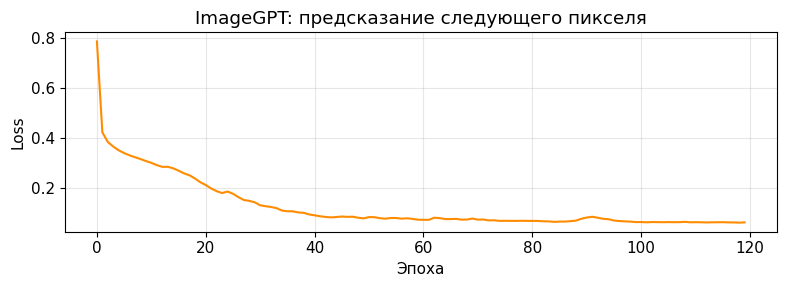

In [ ]:
from tqdm import tqdm

model   = ImageGPT(VOCAB, SEQ_LEN)
opt     = optim.Adam(model.parameters(), lr=3e-3)
loss_fn = nn.CrossEntropyLoss()
losses  = []

for epoch in tqdm(range(120)):
    perm, total = torch.randperm(N), 0.0
    for i in range(0, N, 64):                      # мини-батчи по 64 картинки
        idx      = perm[i:i + 64]
        logit, _ = model(Xs[idx])
        loss     = loss_fn(logit.reshape(-1, VOCAB), Ys[idx].reshape(-1))
        opt.zero_grad(); loss.backward(); opt.step()
        total   += loss.item()
    losses.append(total / (N // 64))

model.eval()
with torch.no_grad():
    logit, attn = model(Xs)                        # attn пригодится в разделе 7
print(f'Точность предсказания следующего пикселя: {(logit.argmax(-1) == Ys).float().mean():.0%}')

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(losses, color='darkorange', linewidth=1.5)
ax.set_xlabel('Эпоха'); ax.set_ylabel('Loss')
ax.set_title('ImageGPT: предсказание следующего пикселя')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

---
## 4. Генерация: пиксель за пикселем

Алгоритм ровно такой же, как при генерации текста:

1. подаём то, что уже есть (сначала — только промпт);
2. смотрим на логиты последней позиции → это распределение цветов следующего пикселя;
3. **сэмплируем** из него (температура — как в текстовом GPT);
4. дописываем пиксель в конец и повторяем 64 раза.

Картинка не появляется целиком — она «дорисовывается» слева направо и сверху вниз.

In [ ]:
@torch.no_grad()
def generate(model, prompt, temperature=0.5, prefix=(), snapshots=()):
    # Рисует картинку по промпту; prefix — уже известные пиксели (для дорисовывания)
    tokens, saved = [prompt] + list(prefix), []

    while len(tokens) - 1 < SEQ_LEN:
        logit, _ = model(torch.tensor([tokens]))
        probs    = torch.softmax(logit[0, -1] / temperature, dim=-1)
        probs[SQUARE:] = 0                       # токены-промпты пикселями быть не могут
        tokens.append(torch.multinomial(probs / probs.sum(), 1).item())

        if len(tokens) - 1 in snapshots:         # сохраняем промежуточный кадр
            canvas = np.full(SEQ_LEN, -1)
            canvas[:len(tokens) - 1] = tokens[1:]
            saved.append(canvas.reshape(SIZE, SIZE))

    img = np.array(tokens[1:]).reshape(SIZE, SIZE)
    return (img, saved) if snapshots else img

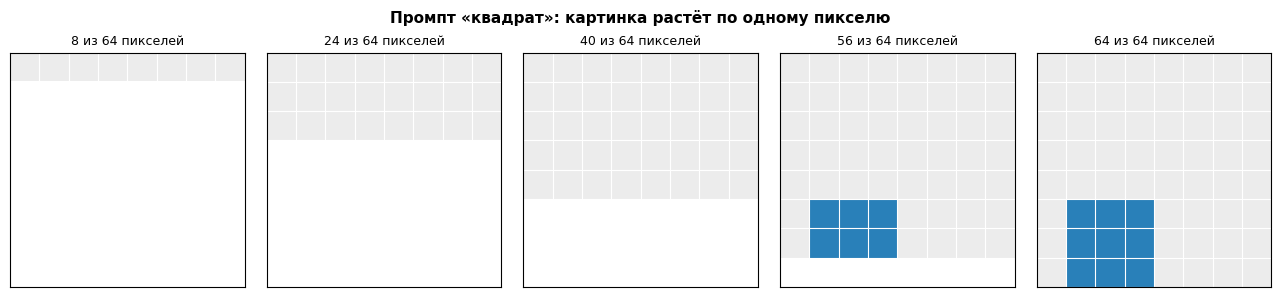

In [ ]:
stages     = (8, 24, 40, 56, 64)
_, frames  = generate(model, SQUARE, snapshots=stages)

fig, axes = plt.subplots(1, len(stages), figsize=(13, 3))
for ax, frame, k in zip(axes, frames, stages):
    show(ax, frame, f'{k} из 64 пикселей')
plt.suptitle('Промпт «квадрат»: картинка растёт по одному пикселю',
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 5. Промпт → картинка

Один и тот же обученный GPT рисует разное — потому что первым токеном мы кладём разный промпт.
Никакого отдельного «механизма понимания текста» здесь нет: промпт просто стоит в той же
последовательности и через внимание влияет на все следующие токены.

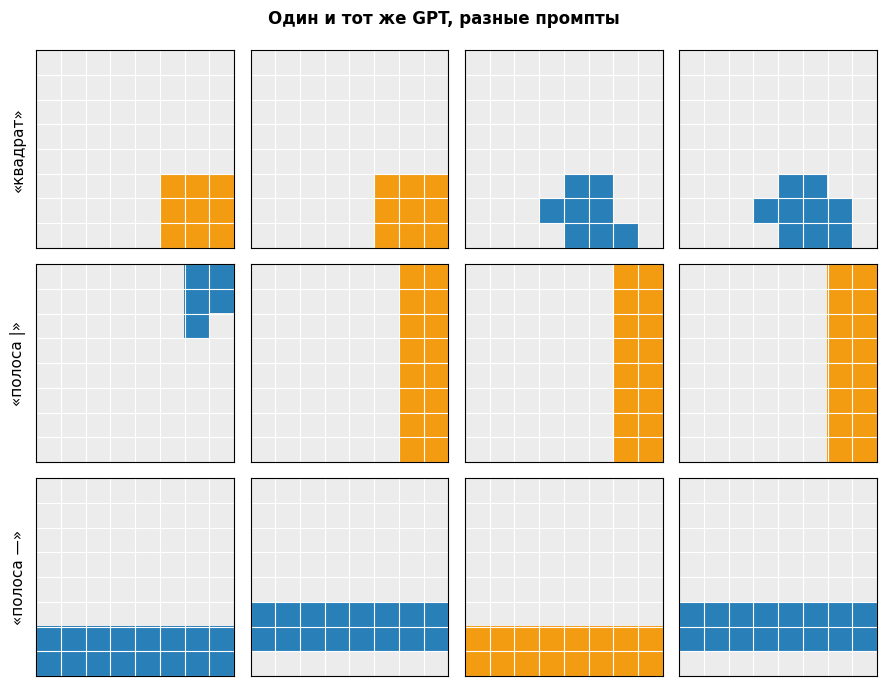

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(9, 7))
for row, p in enumerate([SQUARE, VBAR, HBAR]):
    for ax in axes[row]:
        show(ax, generate(model, p))
    axes[row][0].set_ylabel(f'«{PROMPT_NAME[p]}»', fontsize=11)
plt.suptitle('Один и тот же GPT, разные промпты', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

### Температура — тоже как в тексте

Низкая температура → модель почти всегда берёт самый вероятный цвет: картинки чистые, но однообразные.
Высокая → в распределение попадают маловероятные цвета, и фигура рассыпается в шум.

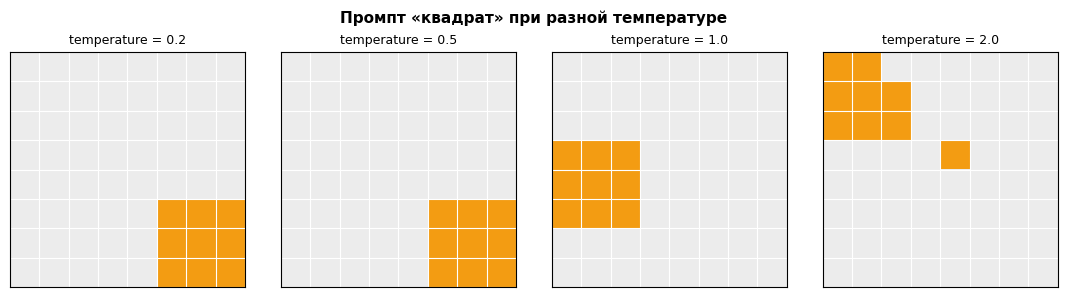

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(11, 3))
for ax, t in zip(axes, [0.2, 0.5, 1.0, 2.0]):
    show(ax, generate(model, SQUARE, temperature=t), f'temperature = {t}')
plt.suptitle('Промпт «квадрат» при разной температуре', fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

---
## 6. Дорисовывание

Раз модель просто продолжает последовательность, ей можно дать **начало картинки** —
и она допишет остальное. Это тот же самый механизм, что и «продолжи текст»,
и на нём основан inpainting в настоящих генераторах.

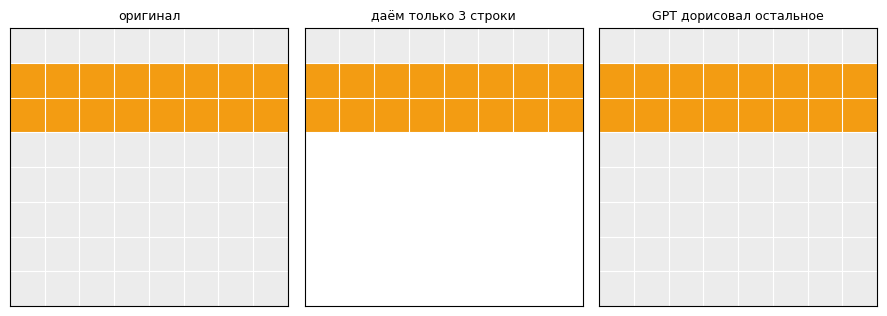

In [ ]:
k      = 3 * SIZE                                  # оставляем первые 3 строки оригинала
orig   = images[0]
prefix = orig.reshape(-1)[:k].tolist()

part       = np.full(SEQ_LEN, -1)
part[:k]   = prefix
completed  = generate(model, int(prompts[0]), prefix=prefix)

fig, axes = plt.subplots(1, 3, figsize=(9, 3.2))
show(axes[0], orig,                    'оригинал')
show(axes[1], part.reshape(SIZE, SIZE), 'даём только 3 строки')
show(axes[2], completed,               'GPT дорисовал остальное')
plt.tight_layout(); plt.show()

---
## 7. Куда смотрит модель

Для модели картинка — плоская строка из 64 чисел, никакой двумерности ей не сообщали.
Посмотрим, на какие уже нарисованные пиксели опирается внимание, когда модель предсказывает
конкретный пиксель (отмечен звёздочкой). Вес усреднён по всей обучающей выборке.

Обратите внимание, распределён ли вес равномерно — или собран в нескольких местах,
связанных с позицией предсказываемого пикселя.

пиксель (3,4): вес на токене-промпте = 0.63
пиксель (6,2): вес на токене-промпте = 0.40


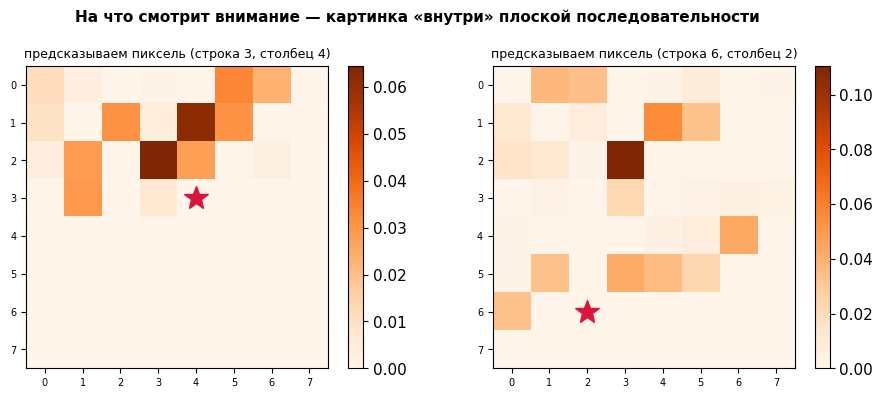

In [ ]:
def attention_map(q):
    # Веса внимания для предсказания пикселя q, разложенные обратно в сетку 8×8
    amap     = np.zeros(SEQ_LEN)
    amap[:q] = attn.mean(0)[q, 1:q + 1].numpy()   # ключ k в последовательности ↔ пиксель k-1
    return amap.reshape(SIZE, SIZE)

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4))
for ax, (r, c) in zip(axes, [(3, 4), (6, 2)]):
    q  = r * SIZE + c
    im = ax.imshow(attention_map(q), cmap='Oranges')
    ax.plot(c, r, marker='*', markersize=18, color='crimson')
    ax.set_xticks(range(SIZE)); ax.set_yticks(range(SIZE))
    ax.tick_params(labelsize=7)
    ax.set_title(f'предсказываем пиксель (строка {r}, столбец {c})', fontsize=9)
    fig.colorbar(im, ax=ax, fraction=0.046)
    print(f'пиксель ({r},{c}): вес на токене-промпте = {attn.mean(0)[q, 0]:.2f}')

plt.suptitle('На что смотрит внимание — картинка «внутри» плоской последовательности',
             fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

---
## Итог

| | |
|---|---|
| Архитектура | тот же декодер, causal self-attention |
| Токен | один пиксель (в реальных моделях — патч или код из VQ-VAE) |
| Предобучение | Next Pixel Prediction |
| Промпт | текстовые токены в начале той же последовательности |
| Генерация | по одному токену, слева направо и сверху вниз |
| Примеры | ImageGPT, DALL·E 1, Parti, генерация картинок в GPT-4o |